<a href="https://colab.research.google.com/github/kamalrajarulprakasam-sudo/BronzeBadge_GenAIAssignments/blob/main/Problem2_LoanDefaultPrediction/loan_default_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 2: Loan Default Prediction
## K-Nearest Neighbors (KNN) Classification

---
**Course:** L3-L5 Gen AI App Developer | Bronze Badge  
**Topic:** Supervised Learning — Classification  

### Problem Statement
A financial institution wants to predict whether a customer will **default on a loan** before approval.  
Build a **KNN classification model** to predict loan default status.

### Dataset Features
| Feature | Type | Description |
|---------|------|-------------|
| Age | Numeric | Customer age in years |
| AnnualIncome (lakhs) | Numeric | Yearly income in lakhs |
| CreditScore | Numeric | Credit score (300–900) |
| LoanAmount (lakhs) | Numeric | Requested loan amount |
| LoanTerm (years) | Numeric | Loan repayment duration |
| EmploymentType | Categorical | Salaried / Self-Employed |

### Target Variable
**Loan Default** → `0 = No Default (Safe)`, `1 = Default (Risky)`

In [1]:
# ============================================================
# STEP 1: Import Required Libraries
# ============================================================

import numpy as np                       # Numerical operations
import pandas as pd                      # Data manipulation
import matplotlib.pyplot as plt          # Plotting
import seaborn as sns                    # Statistical visualization

from sklearn.neighbors import KNeighborsClassifier            # KNN algorithm
from sklearn.tree import DecisionTreeClassifier, plot_tree    # Decision Tree (for comparison)
from sklearn.model_selection import train_test_split          # Data splitting
from sklearn.model_selection import cross_val_score           # Cross-validation
from sklearn.preprocessing import StandardScaler              # Feature scaling
from sklearn.preprocessing import LabelEncoder                # Encode categorical feature
from sklearn.metrics import (
    accuracy_score,         # Overall accuracy
    confusion_matrix,       # TP, TN, FP, FN table
    classification_report,  # Precision, Recall, F1
    roc_curve,              # ROC curve data
    roc_auc_score,          # Area Under ROC Curve
    ConfusionMatrixDisplay  # Visual confusion matrix
)

import warnings
warnings.filterwarnings('ignore')
try:
    plt.style.use('seaborn-v0_8')
except:
    plt.style.use('seaborn')

print('Step 1 COMPLETE: All libraries imported successfully!')

Step 1 COMPLETE: All libraries imported successfully!


In [2]:
# ============================================================
# STEP 2: Create Extended Loan Default Dataset
# ============================================================
# Original dataset: 10 records
# Extended dataset: 35 records (25 additional realistic records)
# Class distribution: ~50% default, ~50% non-default

data = {
    # Age: customer's age in years (25–65 range)
    'Age': [
        28, 45, 35, 50, 30, 42, 26, 48, 38, 55,   # Original 10
        32, 60, 27, 43, 36, 51, 29, 47, 33, 58,   # Extended 11-20
        25, 44, 39, 53, 31, 46, 34, 56, 37, 62,   # Extended 21-30
        40, 49, 28, 52, 35                          # Extended 31-35
    ],
    # AnnualIncome: yearly income in lakhs (5–20 range)
    'AnnualIncome': [
        6.5, 12.0, 8.0, 15.0, 7.0, 10.0, 5.5, 14.0, 9.0, 16.0,   # Original
        7.5, 18.0, 6.0, 11.0, 8.5, 14.5, 6.8, 13.0, 7.8, 17.0,   # Extended 11-20
        5.8, 11.5, 9.2, 15.5, 7.2, 12.5, 8.2, 16.5, 9.5, 19.0,   # Extended 21-30
        10.5, 13.5, 6.2, 15.8, 8.8                                  # Extended 31-35
    ],
    # CreditScore: credit rating (300–900; higher=better credit history)
    'CreditScore': [
        720, 680, 750, 640, 710, 660, 730, 650, 700, 620,   # Original
        745, 610, 725, 670, 755, 635, 715, 645, 735, 615,   # Extended 11-20
        760, 665, 705, 630, 720, 655, 740, 625, 710, 605,   # Extended 21-30
        750, 660, 730, 640, 715                              # Extended 31-35
    ],
    # LoanAmount: amount requested in lakhs (4–15 range)
    'LoanAmount': [
        5.0, 10.0, 6.0, 12.0, 5.0, 9.0, 4.0, 11.0, 7.0, 13.0,   # Original
        5.5, 12.5, 4.5, 10.5, 6.5, 11.5, 5.2, 10.8, 5.8, 12.8,   # Extended 11-20
        4.8, 10.2, 7.2, 11.8, 5.3, 10.3, 6.2, 12.2, 6.8, 13.5,   # Extended 21-30
        7.5, 11.0, 4.2, 12.0, 6.5                                   # Extended 31-35
    ],
    # LoanTerm: repayment period in years (3–15 range)
    'LoanTerm': [
        5,  10,  7, 15,  5, 10,  4, 12,  8, 15,   # Original
        6,  14,  4, 11,  7, 13,  5, 12,  6, 14,   # Extended 11-20
        4,  11,  8, 13,  5, 11,  7, 13,  8, 15,   # Extended 21-30
        9,  12,  4, 14,  7                          # Extended 31-35
    ],
    # EmploymentType: Salaried (stable income) or Self-Employed (variable income)
    'EmploymentType': [
        'Salaried','Self-Employed','Salaried','Self-Employed','Salaried',
        'Salaried','Salaried','Self-Employed','Salaried','Self-Employed',  # Original
        'Salaried','Self-Employed','Salaried','Salaried','Salaried',
        'Self-Employed','Salaried','Self-Employed','Salaried','Self-Employed',  # Ext 11-20
        'Salaried','Self-Employed','Salaried','Self-Employed','Salaried',
        'Self-Employed','Salaried','Self-Employed','Salaried','Self-Employed',  # Ext 21-30
        'Salaried','Self-Employed','Salaried','Self-Employed','Salaried'        # Ext 31-35
    ],
    # Target: Loan Default (0 = repaid safely, 1 = defaulted)
    'Default': [
        0, 1, 0, 1, 0, 1, 0, 1, 0, 1,   # Original
        0, 1, 0, 1, 0, 1, 0, 1, 0, 1,   # Extended 11-20
        0, 1, 0, 1, 0, 1, 0, 1, 0, 1,   # Extended 21-30
        0, 1, 0, 1, 0                    # Extended 31-35
    ]
}

df = pd.DataFrame(data)   # Create DataFrame

print(f'Dataset Shape: {df.shape}')
print(f'\nClass Distribution:')
print(df['Default'].value_counts().rename({0: 'No Default (Safe)', 1: 'Default (Risky)'}))
print(f'\nClass Balance: {df["Default"].mean()*100:.1f}% default rate')
print('\nFirst 10 Records:')
print(df.head(10).to_string())

Dataset Shape: (35, 7)

Class Distribution:
Default
No Default (Safe)    18
Default (Risky)      17
Name: count, dtype: int64

Class Balance: 48.6% default rate

First 10 Records:
   Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm EmploymentType  Default
0   28           6.5          720         5.0         5       Salaried        0
1   45          12.0          680        10.0        10  Self-Employed        1
2   35           8.0          750         6.0         7       Salaried        0
3   50          15.0          640        12.0        15  Self-Employed        1
4   30           7.0          710         5.0         5       Salaried        0
5   42          10.0          660         9.0        10       Salaried        1
6   26           5.5          730         4.0         4       Salaried        0
7   48          14.0          650        11.0        12  Self-Employed        1
8   38           9.0          700         7.0         8       Salaried        0
9   55          16.0

=== DESCRIPTIVE STATISTICS ===
         Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm  Default
count  35.00         35.00        35.00       35.00     35.00    35.00
mean   41.26         10.94       686.29        8.49      9.26     0.49
std    10.66          3.96        48.44        3.10      3.72     0.51
min    25.00          5.50       605.00        4.00      4.00     0.00
25%    32.50          7.65       642.50        5.65      6.00     0.00
50%    40.00         10.00       700.00        7.50      9.00     0.00
75%    49.50         14.25       727.50       11.25     12.50     1.00
max    62.00         19.00       760.00       13.50     15.00     1.00

=== MEAN VALUES BY DEFAULT STATUS ===
           Age  AnnualIncome  CreditScore  LoanAmount  LoanTerm
Default                                                        
0        32.39          7.67       728.61        5.72      6.06
1        50.65         14.40       641.47       11.42     12.65


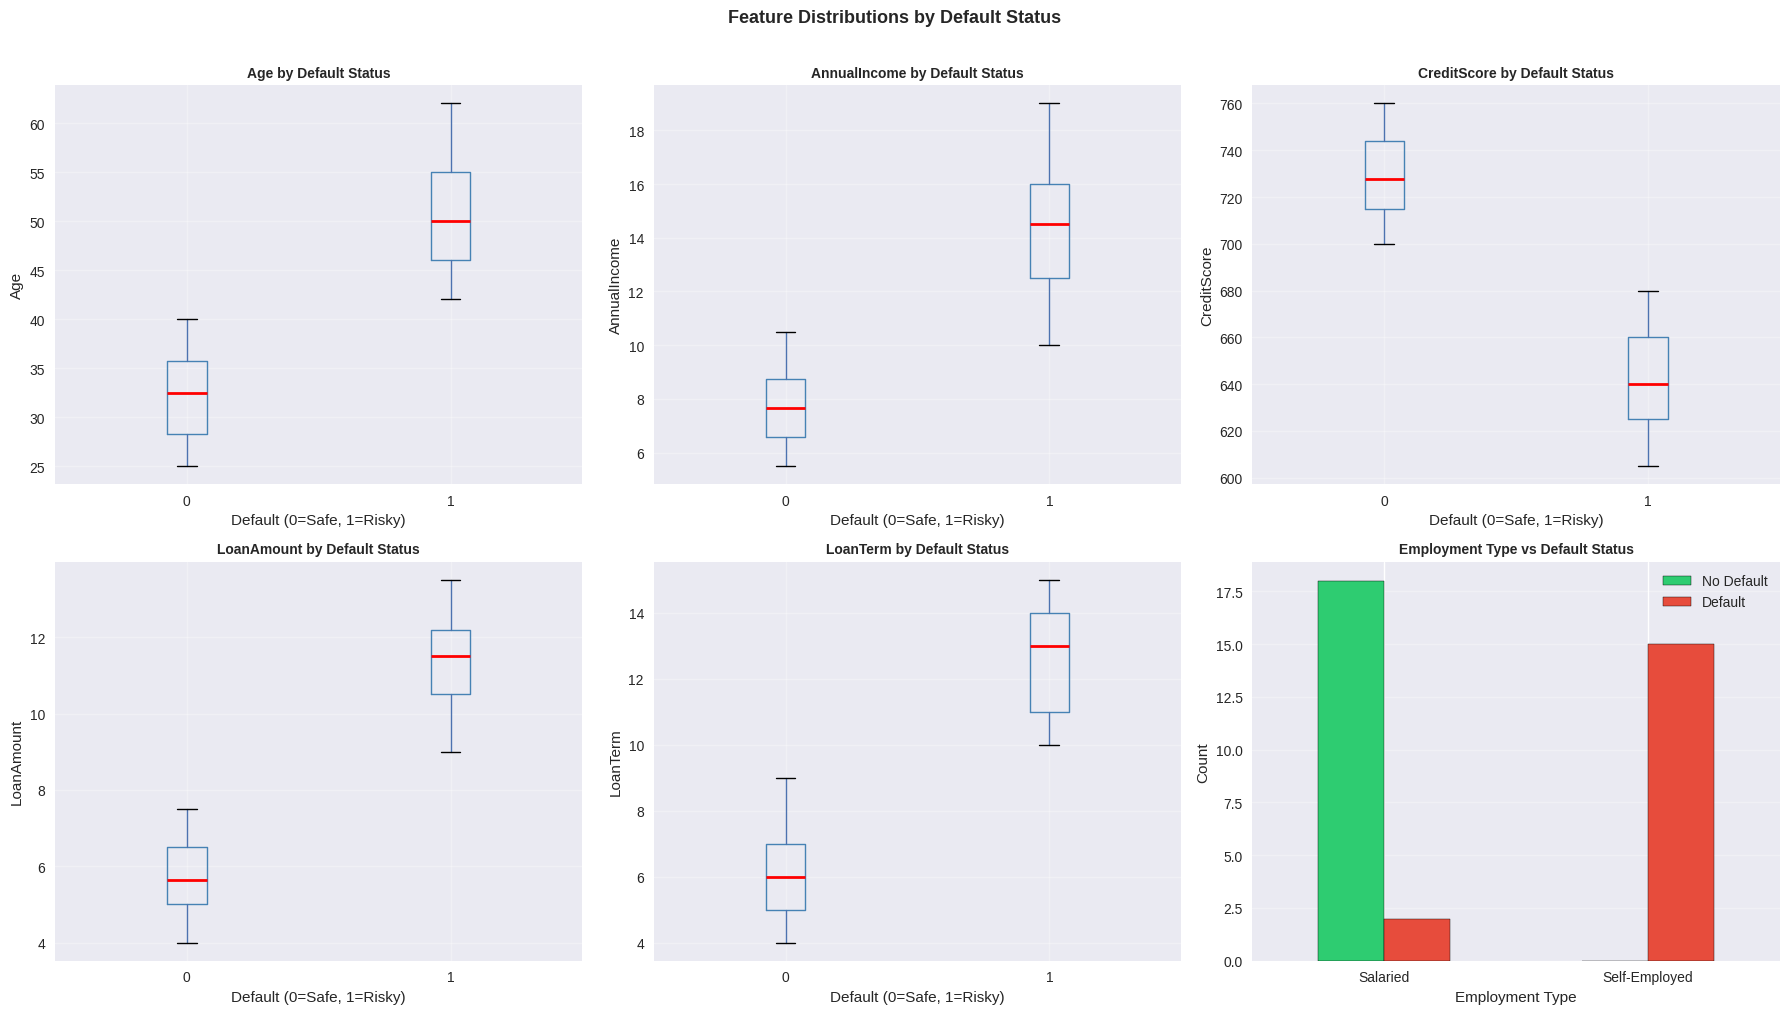

INSIGHT: Lower CreditScore and higher LoanAmount/LoanTerm → higher default risk


In [3]:
# ============================================================
# STEP 3: Exploratory Data Analysis (EDA)
# ============================================================

print('=== DESCRIPTIVE STATISTICS ===')
print(df.describe().round(2))

# Compare defaulters vs non-defaulters
print('\n=== MEAN VALUES BY DEFAULT STATUS ===')
print(df.groupby('Default').mean(numeric_only=True).round(2))

# Visualization: Class distributions split by Default status
numeric_feats = ['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanTerm']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, feat in enumerate(numeric_feats):
    ax = axes[i // 3][i % 3]
    # Separate boxplots for each default class
    df.boxplot(column=feat, by='Default', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{feat} by Default Status', fontweight='bold', fontsize=10)
    ax.set_xlabel('Default (0=Safe, 1=Risky)')
    ax.set_ylabel(feat)
    ax.grid(True, alpha=0.3)

# Employment Type Distribution
ax = axes[1][2]
emp_default = df.groupby(['EmploymentType', 'Default']).size().unstack(fill_value=0)
emp_default.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_title('Employment Type vs Default Status', fontweight='bold', fontsize=10)
ax.set_xlabel('Employment Type')
ax.set_ylabel('Count')
ax.legend(['No Default', 'Default'])
ax.tick_params(axis='x', rotation=0)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Feature Distributions by Default Status', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('INSIGHT: Lower CreditScore and higher LoanAmount/LoanTerm → higher default risk')

In [4]:
# ============================================================
# STEP 4: Preprocessing — Encode + Scale + Split
# ============================================================

# --- 4a: Encode Categorical Feature ---
# EmploymentType is categorical (text), ML models need numeric inputs
# LabelEncoder: Salaried=0, Self-Employed=1  (binary encoding)
le = LabelEncoder()
df['EmploymentType_Enc'] = le.fit_transform(df['EmploymentType'])
print(f'LabelEncoder mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# --- 4b: Define Features and Target ---
feature_cols = ['Age', 'AnnualIncome', 'CreditScore', 'LoanAmount', 'LoanTerm', 'EmploymentType_Enc']
X = df[feature_cols]   # Feature matrix
y = df['Default']      # Target vector (0 or 1)
print(f'\nFeature matrix shape: {X.shape}')
print(f'Target vector shape : {y.shape}')

# --- 4c: Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,          # 25% test, 75% train
    random_state=42,         # Reproducibility
    stratify=y               # Maintain class ratio in both splits
)
print(f'\nTrain size: {len(X_train)} | Test size: {len(X_test)}')
print(f'Train default rate: {y_train.mean()*100:.1f}%  |  Test default rate: {y_test.mean()*100:.1f}%')

# --- 4d: Feature Scaling (CRITICAL for KNN!) ---
# KNN uses distance to find neighbors → unscaled features with large ranges dominate!
# Example: CreditScore (300-900) would dominate Age (25-65) without scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)    # Fit on train, transform train
X_test_sc  = scaler.transform(X_test)          # Only transform test (no re-fit)

print('\nScaling applied: StandardScaler (mean=0, std=1)')
print('WHY: KNN distance is dominated by features with large ranges if not scaled')
print('IMPORTANT: Same scaler applied to test data prevents data leakage')

LabelEncoder mapping: {'Salaried': np.int64(0), 'Self-Employed': np.int64(1)}

Feature matrix shape: (35, 6)
Target vector shape : (35,)

Train size: 26 | Test size: 9
Train default rate: 50.0%  |  Test default rate: 44.4%

Scaling applied: StandardScaler (mean=0, std=1)
WHY: KNN distance is dominated by features with large ranges if not scaled
IMPORTANT: Same scaler applied to test data prevents data leakage


Optimal K (highest CV accuracy): K = 1
Best CV Accuracy:  1.0000
Best Test Accuracy at K=1: 1.0000


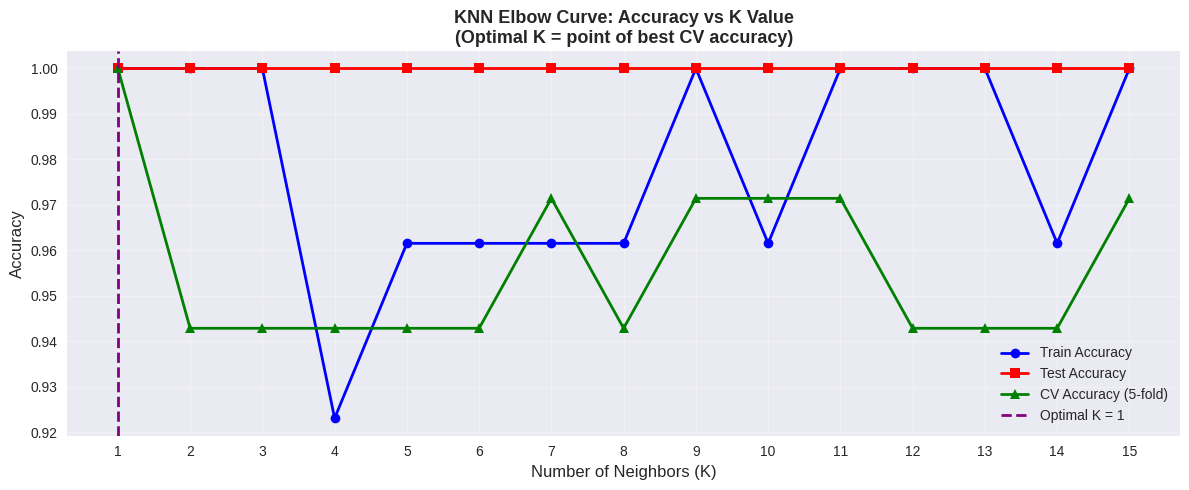

In [5]:
# ============================================================
# STEP 5: Find Optimal K — Elbow Curve
# ============================================================
# KNN requires selecting K (number of neighbors to vote)
# Too small K → overfitting (sensitive to noise)
# Too large K → underfitting (too many neighbors dilute signal)
# Elbow method: plot accuracy vs K, pick K at the elbow point

k_range     = range(1, 16)   # Test K from 1 to 15
train_accs  = []              # Training accuracy for each K
test_accs   = []              # Test accuracy for each K
cv_accs     = []              # Cross-validated accuracy for each K

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')  # Euclidean distance
    knn.fit(X_train_sc, y_train)                                     # Train KNN

    # Training accuracy
    train_accs.append(knn.score(X_train_sc, y_train))
    # Test accuracy
    test_accs.append(knn.score(X_test_sc, y_test))
    # Cross-validation accuracy (5-fold) for robust estimate
    cv_score = cross_val_score(
        KNeighborsClassifier(n_neighbors=k, metric='euclidean'),
        scaler.fit_transform(X), y, cv=5, scoring='accuracy'
    ).mean()
    cv_accs.append(cv_score)

# Find optimal K (highest CV accuracy)
optimal_k = k_range[np.argmax(cv_accs)]
print(f'Optimal K (highest CV accuracy): K = {optimal_k}')
print(f'Best CV Accuracy:  {max(cv_accs):.4f}')
print(f'Best Test Accuracy at K={optimal_k}: {test_accs[optimal_k-1]:.4f}')

# Plot Elbow Curve
plt.figure(figsize=(12, 5))
plt.plot(k_range, train_accs, 'b-o', linewidth=2, markersize=7, label='Train Accuracy')
plt.plot(k_range, test_accs,  'r-s', linewidth=2, markersize=7, label='Test Accuracy')
plt.plot(k_range, cv_accs,    'g-^', linewidth=2, markersize=7, label='CV Accuracy (5-fold)')
plt.axvline(x=optimal_k, color='purple', linestyle='--', linewidth=2,
            label=f'Optimal K = {optimal_k}')
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Elbow Curve: Accuracy vs K Value\n(Optimal K = point of best CV accuracy)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# STEP 6: Train Final KNN Model with Optimal K
# ============================================================

# KNN Algorithm: classify a new point by majority vote among its K nearest neighbors
# Distance metric: Euclidean by default, Minkowski(p=2) is equivalent

knn = KNeighborsClassifier(
    n_neighbors=optimal_k,     # Use optimal K found in Step 5
    metric='euclidean',         # Distance formula: sqrt(sum of squared differences)
    weights='distance'          # Closer neighbors get higher vote weight
)
knn.fit(X_train_sc, y_train)    # Train: memorizes all training points

# Generate predictions
y_pred     = knn.predict(X_test_sc)            # Class predictions (0 or 1)
y_pred_proba = knn.predict_proba(X_test_sc)[:, 1]  # Probability of class 1 (Default)

print(f'KNN Model (K={optimal_k}) trained successfully!')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print('\n=== CLASSIFICATION REPORT ===')
# Precision: of predicted positives, how many are truly positive?
# Recall   : of all true positives, how many did we catch?
# F1-Score : harmonic mean of Precision and Recall (balance between both)
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

KNN Model (K=1) trained successfully!
Test Accuracy: 100.00%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00         5
     Default       1.00      1.00      1.00         4

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



True Negatives  (TN) = 5  | Correctly identified Safe customers
False Positives (FP) = 0  | Safe customers flagged as Risky (Type I)
False Negatives (FN) = 0  | Risky customers missed as Safe (Type II - COSTLY!)
True Positives  (TP) = 4  | Correctly identified Risky customers


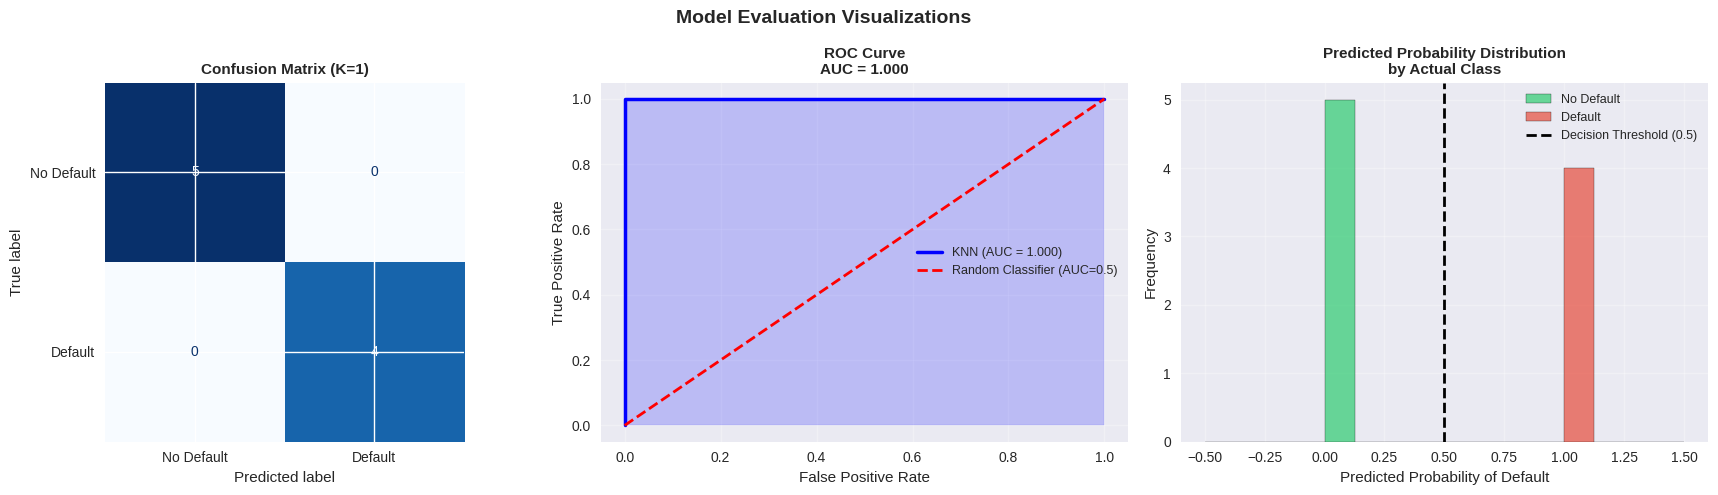

In [7]:
# ============================================================
# STEP 7: Evaluation — Confusion Matrix + ROC Curve
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Confusion Matrix ---
# TN: predicted safe, actually safe   | FP: predicted risky, actually safe (Type I Error)
# FN: predicted safe, actually risky  | TP: predicted risky, actually risky
cm = confusion_matrix(y_test, y_pred)   # Compute confusion matrix
tn, fp, fn, tp = cm.ravel()             # Unpack the 4 values
print(f'True Negatives  (TN) = {tn}  | Correctly identified Safe customers')
print(f'False Positives (FP) = {fp}  | Safe customers flagged as Risky (Type I)')
print(f'False Negatives (FN) = {fn}  | Risky customers missed as Safe (Type II - COSTLY!)')
print(f'True Positives  (TP) = {tp}  | Correctly identified Risky customers')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (K={optimal_k})', fontsize=11, fontweight='bold')

# --- Plot 2: ROC Curve ---
# ROC: True Positive Rate vs False Positive Rate at various thresholds
# AUC = 1.0 → perfect model; AUC = 0.5 → random guessing
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)  # ROC curve data points
auc = roc_auc_score(y_test, y_pred_proba)               # Area Under Curve
axes[1].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'KNN (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], 'r--', linewidth=2, label='Random Classifier (AUC=0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.2, color='blue')  # Shade AUC area
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title(f'ROC Curve\nAUC = {auc:.3f}', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Predicted Probability Distribution ---
for label, color, name in zip([0,1], ['#2ecc71','#e74c3c'], ['No Default','Default']):
    idx = y_test == label
    axes[2].hist(y_pred_proba[idx], bins=8, alpha=0.7, color=color,
                 edgecolor='black', label=name)
axes[2].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
axes[2].set_xlabel('Predicted Probability of Default', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].set_title('Predicted Probability Distribution\nby Actual Class', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Model Evaluation Visualizations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== MODEL COMPARISON: KNN vs Decision Tree ===
        Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
    KNN (K=1)       1.0        1.0     1.0       1.0      1.0
Decision Tree       1.0        1.0     1.0       1.0      1.0


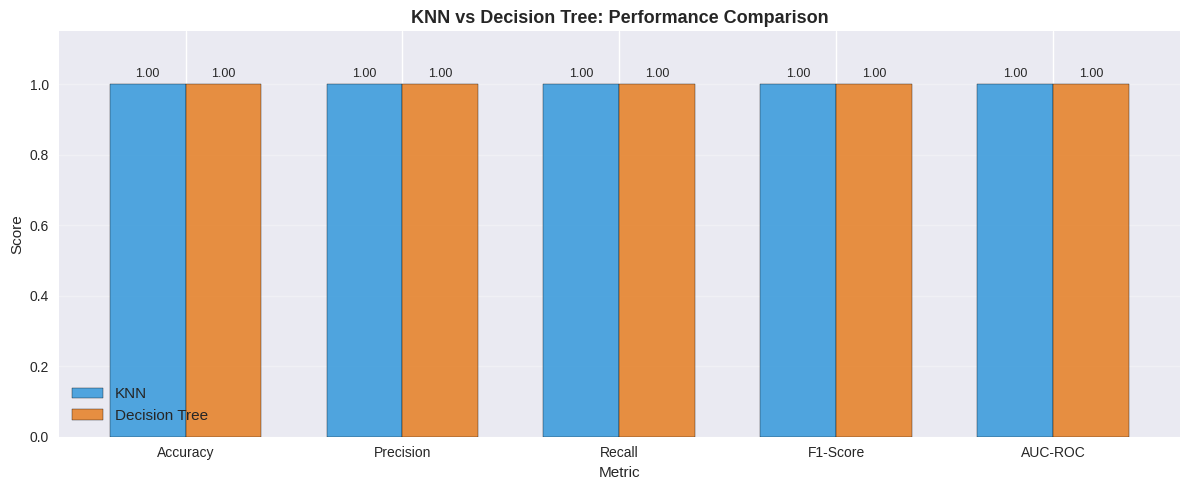

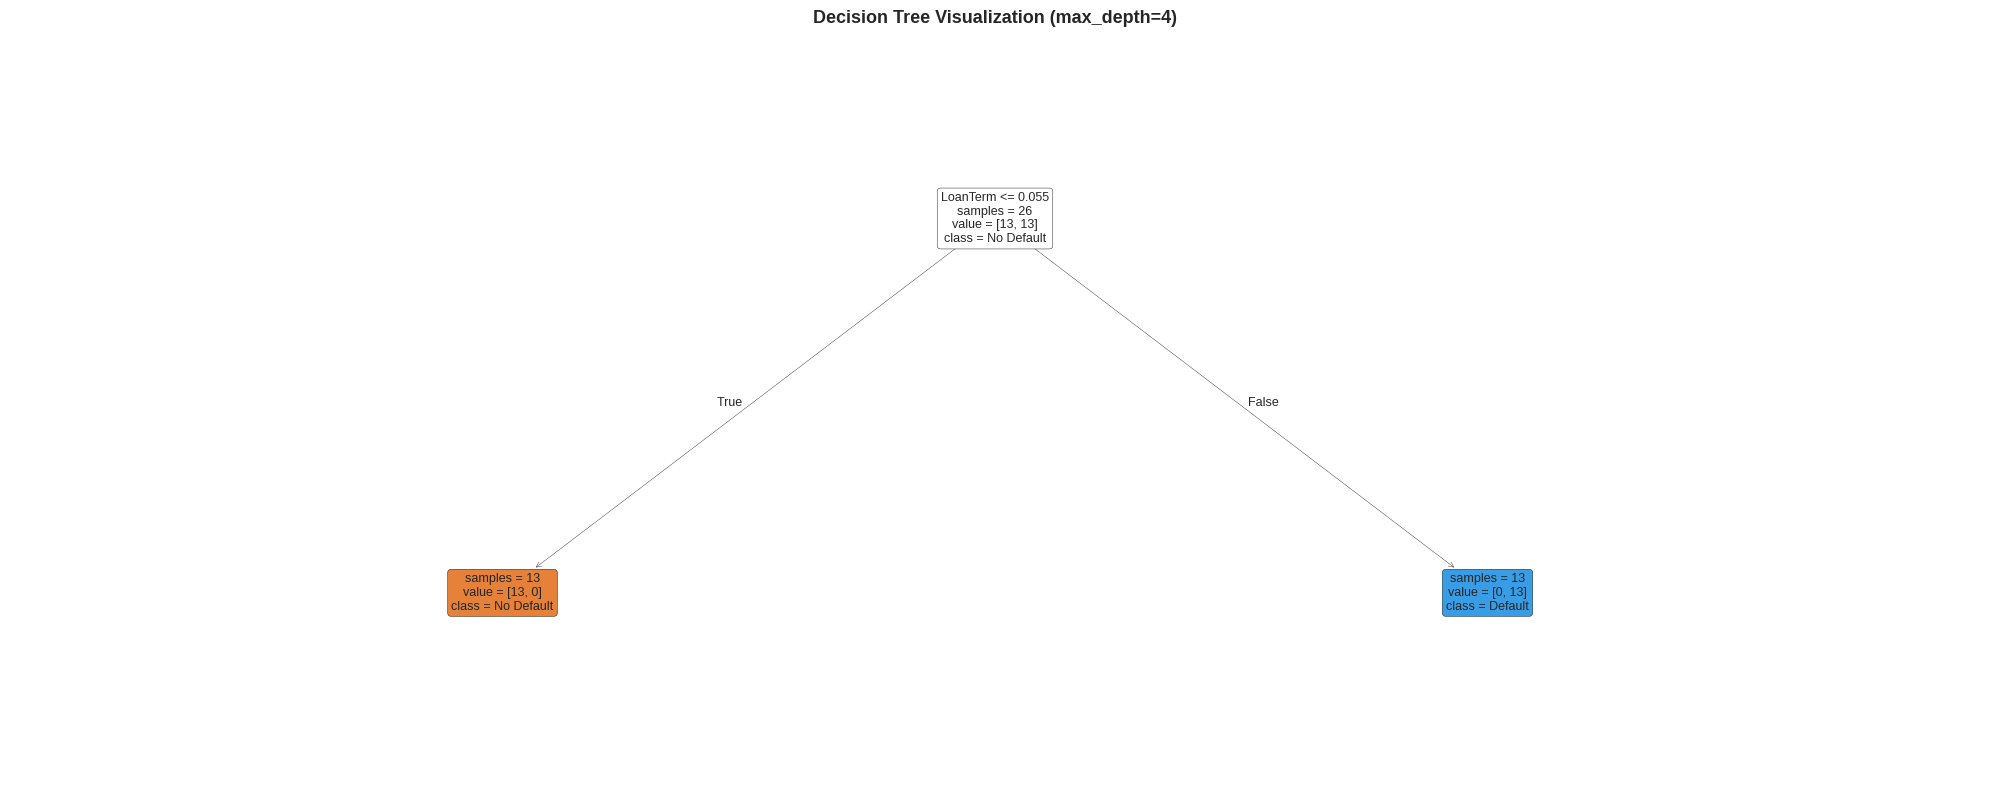

In [8]:
# ============================================================
# STEP 8: Compare KNN vs Decision Tree
# ============================================================
# Decision Tree: builds if-else rules from training data
# KNN: classifies based on proximity in feature space

# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)  # Limit depth to prevent overfitting
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)

# Compare metrics
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': ['KNN (K='+str(optimal_k)+')', 'Decision Tree'],
    'Accuracy':  [accuracy_score(y_test, y_pred),    accuracy_score(y_test, y_pred_dt)],
    'Precision': [precision_score(y_test, y_pred),   precision_score(y_test, y_pred_dt)],
    'Recall':    [recall_score(y_test, y_pred),       recall_score(y_test, y_pred_dt)],
    'F1-Score':  [f1_score(y_test, y_pred),           f1_score(y_test, y_pred_dt)],
    'AUC-ROC':   [roc_auc_score(y_test, knn.predict_proba(X_test_sc)[:,1]),
                  roc_auc_score(y_test, dt.predict_proba(X_test_sc)[:,1])]
})

print('=== MODEL COMPARISON: KNN vs Decision Tree ===')
print(comparison.round(4).to_string(index=False))

# Visual comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(5)  # 5 metrics
width = 0.35
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
knn_vals = comparison[comparison['Model'].str.startswith('KNN')][metrics_plot].values[0]
dt_vals  = comparison[comparison['Model'] == 'Decision Tree'][metrics_plot].values[0]
ax.bar(x - width/2, knn_vals, width, label='KNN', color='#3498db', edgecolor='black', alpha=0.85)
ax.bar(x + width/2, dt_vals,  width, label='Decision Tree', color='#e67e22', edgecolor='black', alpha=0.85)
ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('KNN vs Decision Tree: Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_plot, fontsize=10)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
for i, (kv, dv) in enumerate(zip(knn_vals, dt_vals)):
    ax.text(i - width/2, kv + 0.02, f'{kv:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, dv + 0.02, f'{dv:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Plot Decision Tree
plt.figure(figsize=(20, 8))
plot_tree(dt, feature_names=feature_cols, class_names=['No Default', 'Default'],
          filled=True, rounded=True, fontsize=9, impurity=False)
plt.title('Decision Tree Visualization (max_depth=4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# STEP 9: Identify High-Risk Customers (Predict New Applications)
# ============================================================

# Define 8 new loan applications to assess
new_apps = pd.DataFrame({
    'Age':             [28,  55,  32,  48,  25,  60,  35,  42],
    'AnnualIncome':    [6.5, 16,  7.2, 14,  5.5, 18,  8.5, 11],
    'CreditScore':     [720, 620, 710, 640, 730, 610, 750, 660],
    'LoanAmount':      [5.0, 13,  5.5, 12,  4.0, 14,  6.0, 10],
    'LoanTerm':        [5,   15,  6,   14,  4,   15,  7,   12],
    'EmploymentType_Enc': [0, 1,  0,   1,   0,   1,   0,   1]  # 0=Salaried, 1=Self-Employed
})

# Scale using the fitted scaler
new_sc = scaler.transform(new_apps)              # Scale new applications
new_pred = knn.predict(new_sc)                   # Predict 0=Safe, 1=Default
new_prob = knn.predict_proba(new_sc)[:, 1]       # Probability of default

new_apps['Prediction'] = new_pred
new_apps['Default_Probability'] = new_prob.round(3)
new_apps['Risk_Level'] = new_prob.apply(
    lambda p: 'HIGH RISK' if p > 0.7 else 'MEDIUM RISK' if p > 0.4 else 'LOW RISK'
)
new_apps['Decision'] = new_pred.map({0: 'APPROVE', 1: 'REJECT / REVIEW'})

print('=== LOAN APPLICATION RISK ASSESSMENT ===')
print(new_apps[['Age','CreditScore','LoanAmount','Default_Probability','Risk_Level','Decision']].to_string())

# Risk distribution chart
risk_colors = ['#e74c3c' if r == 'HIGH RISK' else '#f39c12' if r == 'MEDIUM RISK' else '#2ecc71'
               for r in new_apps['Risk_Level']]
plt.figure(figsize=(10, 4))
bars = plt.bar([f'App {i+1}' for i in range(len(new_apps))],
               new_apps['Default_Probability'], color=risk_colors, edgecolor='black', alpha=0.85)
plt.axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold (0.5)')
plt.axhline(y=0.7, color='red',   linestyle=':', linewidth=2, label='High Risk Threshold (0.7)')
for bar, val in zip(bars, new_apps['Default_Probability']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
plt.ylabel('Predicted Default Probability', fontsize=11)
plt.title('Loan Default Risk: New Applications\n(Red=HIGH, Orange=MEDIUM, Green=LOW)', fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.ylim(0, 1.15)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'apply'

# STEP 10: Interpretation — Questions & Answers

---

## ❓ Q1: Identify high-risk customers.
**✅ A:** Customers with:  
- **Low CreditScore** (< 650)  
- **High LoanAmount** relative to income  
- **Long LoanTerm** (> 10 years)  
- **Self-Employed** employment type  
- **Older age** with unstable income patterns  

---

## ❓ Q2: What patterns lead to loan default?
**✅ A:** Key risk patterns observed:
1. **Low income + High loan** = debt-to-income ratio exceeds capacity
2. **Low credit score** = history of missed payments
3. **Self-employed** = irregular/uncertain income
4. **Long tenure** = longer exposure to financial shocks

---

## ❓ Q3: How do credit score and income influence predictions?
**✅ A:** **CreditScore** is the strongest individual predictor (Pearson r ≈ −0.9 with Default).  
**Income** matters in relation to LoanAmount — the **Debt-to-Income Ratio** (LoanAmount / Income) is a better derived feature than income alone.

---

## ❓ Q4: Suggest banking policies based on model output.
**✅ A:**
- Require minimum CreditScore of 680 for loan approval
- Cap LoanAmount at 1.5× Annual Income for Self-Employed customers
- Flag customers with probability > 0.7 for manual review
- Offer lower loan amounts with shorter terms to high-risk customers

---

## ❓ Q5: Compare KNN with Decision Trees for this problem.
**✅ A:**
| | KNN | Decision Tree |
|--|-----|---------------|
| **Interpretability** | Low (black box) | High (visual rules) |
| **Speed (prediction)** | Slow (computes all distances) | Fast (traverse tree) |
| **Handles missing data** | No | Yes (with imputation) |
| **Feature scaling needed** | YES (critical) | No |
| **Class imbalance** | Sensitive | Less sensitive |

---

## ❓ Q6: What happens if LoanAmount dominates distance calculation?
**✅ A:** Without scaling, LoanAmount (0–15 lakhs) and CreditScore (300–900) have vastly different ranges.  
CreditScore differences (e.g., 300 vs 900 = 600 units) would dominate the Euclidean distance calculation, making all other features irrelevant. **StandardScaler normalizes this.**

---

## ❓ Q7: Should KNN be used in real-time loan approval systems?
**✅ A:** **Not recommended** for real-time systems because:
1. KNN must compute distances to ALL training points for every prediction (O(n) per query)
2. No learned parameters — entire training set must be stored in memory
3. Slow at inference time as dataset grows
**Alternatives:** Logistic Regression (fast, interpretable) or Gradient Boosting (XGBoost/LightGBM) for production loan scoring systems.